## GymVibe: гибридная контекстная рекомендательная система

Система подбора музыки для тренировок, которая адаптируется под текущую интенсивность (аудио-архетипы) и персональный темп пользователя.

Архитектура: Two-Stage Recommender System.

1. **Retrieval (L0):** двухбашенная нейросеть (Two-Tower / DSSM) на PyTorch ищет кандидатов по векторной близости пользователя и трека.
2. **Ranking (L1):** CatBoost с функцией потерь YetiRank переранжирует кандидатов с учётом контекста тренировки.

Датасет содержит каталог песен, а не реальные события. Поэтому ниже создаются синтетические implicit-feedback логи, NDCG@5 — метрика этого воспроизводимого офлайн-эксперимента.

### Настройки и импорт

In [44]:
from __future__ import annotations
import warnings

import random
import re
from dataclasses import dataclass
from typing import Iterable

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
import seaborn as sns
from catboost import CatBoostRanker, Pool
from sklearn.metrics import ndcg_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn import functional as F

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

SEED = 42
VIBE_LABELS = [
    "Boss Fight / Doom Slayer", "Zen / Lo-Fi Recovery",
    "Golden Era (Old School)", "Pilates Girl", "Pure Rage / Metalhead",
    "Sigma Grindset", "Пацанский Вайб",
]
ITEM_FEATURES = [
    "bpm", "gain", "street_score", "lyrics_word_count", "power_index", "word_density",
]
RANK_FEATURES = ITEM_FEATURES + ["context", "genre_final", "user_pref_bpm", "nn_score"]


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

### 1. Feature Engineering & Preprocessing

- Акустические признаки
- **Power Index:** соотношение темпа и громкости (энергетика трека).
- **Street Score:** счётчик уличных маркеров в тексте.
- **Word Density:** плотность текста относительно длительности.


In [45]:
class FeatureProcessor:
    def __init__(self) -> None:
        self.item_scaler = StandardScaler()
        self.bpm_scaler = StandardScaler()
        self.fitted = False

    @staticmethod
    def add_features(df: pd.DataFrame) -> pd.DataFrame:
        result = df.copy()
        lyrics = result["clean_lyrics"].fillna("").astype(str).str.lower()
        lyrics = lyrics.str.replace(r"\[.*?\]", "", regex=True)
        street_words = ("street", "block", "gang", "money", "hustle", "choppa", "glock")
        result["street_score"] = lyrics.map(lambda text: sum(word in text for word in street_words))
        duration_sec = pd.to_numeric(result["itunes_duration_ms"], errors="coerce").fillna(0) / 1000
        result["word_density"] = result["lyrics_word_count"].fillna(0) / (duration_sec + 1)
        result["power_index"] = result["bpm"].fillna(0) * (result["gain"].fillna(-10) + 25) / 100
        return result

    def fit(self, df: pd.DataFrame) -> "FeatureProcessor":
        enriched = self.add_features(df)
        self.item_scaler.fit(enriched[ITEM_FEATURES].fillna(0))
        self.bpm_scaler.fit(enriched[["bpm"]].fillna(0))
        self.fitted = True
        return self

    def transform_items(self, df: pd.DataFrame) -> pd.DataFrame:
        if not self.fitted:
            raise RuntimeError("FeatureProcessor must be fitted before transformation")
        result = self.add_features(df)
        result[ITEM_FEATURES] = self.item_scaler.transform(result[ITEM_FEATURES].fillna(0))
        return result

    def transform_preference(self, bpm: Iterable[float]) -> np.ndarray:
        values = pd.DataFrame({"bpm": np.asarray(list(bpm), dtype="float32")})
        return self.bpm_scaler.transform(values).astype("float32")

### 2. Retrieval Layer (Two-Tower Neural Network)

User Tower получает нормализованный preferred BPM и one-hot контекст тренировки. Item Tower получает engineered-признаки трека. Положительные пары обучаются с in-batch negatives.

In [46]:
class Tower(nn.Module):
    def __init__(self, in_features: int, embedding_dim: int) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, embedding_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.network(x), dim=1)


class TwoTowerDSSM(nn.Module):
    def __init__(self, item_dim: int, n_contexts: int, embedding_dim: int = 32) -> None:
        super().__init__()
        self.user_tower = Tower(1 + n_contexts, embedding_dim)
        self.item_tower = Tower(item_dim, embedding_dim)

    def forward(self, user: torch.Tensor, item: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        return self.user_tower(user), self.item_tower(item)

### 3. Ranking Layer (CatBoost YetiRank)

Retrieval возвращает top-K кандидатов. Затем CatBoostRanker с YetiRank использует neural score, контекст, жанр, preferred BPM и признаки трека. Группа ранжирования — сессия показа.

In [47]:
def generate_interactions(catalogue: pd.DataFrame, n_users: int = 200,
                          sessions_per_user: int = 4, tracks_per_session: int = 20,
                          seed: int = SEED) -> pd.DataFrame:
    catalogue = catalogue.drop_duplicates("track_name").copy()
    rng = np.random.default_rng(seed)
    rows: list[dict] = []
    bpm = catalogue["bpm"].fillna(catalogue["bpm"].median())
    for user_id in range(n_users):
        preference = float(np.clip(rng.normal(bpm.median(), bpm.std() * .5), bpm.min(), bpm.max()))
        for session_no in range(sessions_per_user):
            context = str(rng.choice(VIBE_LABELS))
            context_pool = catalogue.loc[catalogue["target"] == context]
            positives = context_pool.sample(min(tracks_per_session // 2, len(context_pool)),
                                            random_state=int(rng.integers(1_000_000)))
            random_pool = catalogue.sample(tracks_per_session - len(positives),
                                            random_state=int(rng.integers(1_000_000)))
            displayed = pd.concat([positives, random_pool]).drop_duplicates("track_name")
            for _, song in displayed.iterrows():
                probability = .03 + .45 * (song.target == context)
                distance = abs(float(song.bpm) - preference)
                probability += .35 if distance <= 8 else (.15 if distance <= 16 else 0)
                rows.append({"user_id": user_id, "session_id": f"{user_id}_{session_no}",
                             "track_name": song.track_name, "user_pref_bpm": preference,
                             "context": context, "like": int(rng.random() < min(probability, .95))})
    return pd.DataFrame(rows)

In [48]:
@dataclass
class EvaluationResult:
    score: float
    evaluated_sessions: int
    
    
class GymVibeRecSys:
    def __init__(self, catalogue: pd.DataFrame, embedding_dim: int = 32) -> None:
        self.catalogue_raw = catalogue.drop_duplicates("track_name").copy()
        self.embedding_dim = embedding_dim
        self.processor = FeatureProcessor()
        self.context_to_id = {name: index for index, name in enumerate(VIBE_LABELS)}
        self.model: TwoTowerDSSM | None = None
        self.ranker: CatBoostRanker | None = None
        self.catalogue: pd.DataFrame | None = None
        self.train_pool: Pool | None = None

    def _user_matrix(self, frame: pd.DataFrame) -> np.ndarray:
        pref = self.processor.transform_preference(frame["user_pref_bpm"])
        context = np.zeros((len(frame), len(VIBE_LABELS)), dtype="float32")
        for row, vibe in enumerate(frame["context"]):
            context[row, self.context_to_id[str(vibe)]] = 1.0
        return np.hstack([pref, context])

    def _score_retrieval(self, frame: pd.DataFrame) -> np.ndarray:
        assert self.model is not None
        self.model.eval()
        with torch.no_grad():
            users = torch.tensor(self._user_matrix(frame), dtype=torch.float32)
            items = torch.tensor(frame[ITEM_FEATURES].to_numpy(dtype="float32"), dtype=torch.float32)
            return (self.model.user_tower(users) * self.model.item_tower(items)).sum(dim=1).numpy()

    def fit(self, train_logs: pd.DataFrame, epochs: int = 40, lr: float = 3e-3) -> "GymVibeRecSys":
        seed_everything()
        train_catalogue = self.catalogue_raw.loc[self.catalogue_raw.track_name.isin(train_logs.track_name)]
        self.processor.fit(train_catalogue)
        self.catalogue = self.processor.transform_items(self.catalogue_raw)
        train = train_logs.merge(self.catalogue, on="track_name", how="inner", validate="many_to_one")
        positive = train.loc[train.like == 1].reset_index(drop=True)
        if len(positive) < 2:
            raise ValueError("At least two positive interactions are needed for Two-Tower training")
        self.model = TwoTowerDSSM(len(ITEM_FEATURES), len(VIBE_LABELS), self.embedding_dim)
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)
        users = torch.tensor(self._user_matrix(positive), dtype=torch.float32)
        items = torch.tensor(positive[ITEM_FEATURES].to_numpy(dtype="float32"), dtype=torch.float32)
        self.model.train()
        for _ in range(epochs):
            user_embeddings, item_embeddings = self.model(users, items)
            logits = user_embeddings @ item_embeddings.T / 0.1
            labels = torch.arange(len(positive))
            loss = F.cross_entropy(logits, labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()

        train["nn_score"] = self._score_retrieval(train)
        train = train.sort_values("session_id")
        self.train_pool = Pool(train[RANK_FEATURES], label=train.like, group_id=train.session_id,
                               cat_features=["context", "genre_final"])
        self.ranker = CatBoostRanker(iterations=500, learning_rate=.04, depth=6,
                                     loss_function="YetiRank", eval_metric="NDCG:top=5",
                                     random_seed=SEED, verbose=False)
        self.ranker.fit(self.train_pool)
        return self

    def retrieve_candidates(self, candidate_requests: pd.DataFrame, retrieval_k: int = 50) -> pd.DataFrame:
        if self.model is None or self.catalogue is None:
            raise RuntimeError("Fit the system before retrieving candidates")
        frame = candidate_requests.merge(self.catalogue, on="track_name", how="inner", validate="many_to_one")
        frame["nn_score"] = self._score_retrieval(frame)
        frame["context_match"] = frame["target"].eq(frame["context"])
        return frame.nlargest(min(retrieval_k, len(frame)), "nn_score").copy()

    def rank_candidates(self, retrieved_candidates: pd.DataFrame) -> pd.DataFrame:
        if self.ranker is None:
            raise RuntimeError("Fit the system before ranking candidates")
        ranked = retrieved_candidates.copy()
        ranked["final_score"] = self.ranker.predict(ranked[RANK_FEATURES])
        return ranked.sort_values("final_score", ascending=False)

    def recommend(self, user_pref_bpm: float, context: str, n: int = 5, retrieval_k: int = 50) -> pd.DataFrame:
        request = self.catalogue_raw[["track_name"]].copy()
        request["user_pref_bpm"], request["context"] = user_pref_bpm, context
        retrieved = self.retrieve_candidates(request, retrieval_k=retrieval_k)
        ranked = self.rank_candidates(retrieved)
        return ranked.head(n)

    def evaluate_ranking_on_displayed_candidates(self, test_logs: pd.DataFrame, k: int = 5,
                                                 retrieval_k: int = 50) -> EvaluationResult:
        scores: list[float] = []
        for _, session in test_logs.groupby("session_id"):
            if session.like.sum() == 0:
                continue
            retrieved = self.retrieve_candidates(session, retrieval_k)
            ranked = self.rank_candidates(retrieved)
            scores.append(float(ndcg_score(ranked.like.to_numpy()[None, :],
                                           ranked.final_score.to_numpy()[None, :], k=k)))
        return EvaluationResult(float(np.mean(scores)) if scores else float("nan"), len(scores))

    def evaluate_retrieval_recall(self, test_logs: pd.DataFrame, retrieval_k: int = 50) -> EvaluationResult:
        recalls: list[float] = []
        for _, session in test_logs.groupby("session_id"):
            relevant = set(session.loc[session.like == 1, "track_name"])
            if not relevant:
                continue
            request = self.catalogue_raw[["track_name"]].copy()
            request["user_pref_bpm"] = float(session.user_pref_bpm.iloc[0])
            request["context"] = str(session.context.iloc[0])
            retrieved = self.retrieve_candidates(request, retrieval_k)
            retrieved_names = set(retrieved.track_name)
            recalls.append(len(relevant & retrieved_names) / len(relevant))
        return EvaluationResult(float(np.mean(recalls)) if recalls else float("nan"), len(recalls))

#### Оценка модели (NDCG)

Train/test разделены по пользователям. NDCG@5 для каждой тестовой сессии Retrieval ранжирует только показанные в ней треки, затем CatBoost выполняет Ranking. Качество полно-каталожного Retrieval отдельно измеряется Recall@50.

In [49]:
def split_logs_by_user(logs: pd.DataFrame, test_size: float = .2) -> tuple[pd.DataFrame, pd.DataFrame]:
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=SEED)
    train_idx, test_idx = next(splitter.split(logs, groups=logs.user_id))
    return logs.iloc[train_idx].copy(), logs.iloc[test_idx].copy()


def context_hit_rate(recsys: GymVibeRecSys, test_logs: pd.DataFrame, k: int = 5) -> float:
    hits: list[bool] = []
    for _, session in test_logs.groupby("session_id"):
        recommendations = recsys.recommend(
            user_pref_bpm=float(session["user_pref_bpm"].iloc[0]),
            context=str(session["context"].iloc[0]),
            n=k,
        )
        hits.extend(recommendations["context_match"].tolist())
    return float(np.mean(hits)) if hits else float("nan")

### 4. Запуск пайплайна

In [50]:
catalogue = pd.read_csv('featured_data_1.csv')
logs = generate_interactions(catalogue, n_users=200, sessions_per_user=4, tracks_per_session=20)
train_logs, test_logs = split_logs_by_user(logs, test_size=0.20)

system = GymVibeRecSys(catalogue, embedding_dim=32)
system.fit(train_logs, epochs=40)

retrieval_result = system.evaluate_retrieval_recall(test_logs, retrieval_k=50)
ranking_result = system.evaluate_ranking_on_displayed_candidates(test_logs, k=5, retrieval_k=50)
print(f'Retrieval Recall@50: {retrieval_result.score:.4f} over {retrieval_result.evaluated_sessions} held-out sessions')
print(f'Ranking NDCG@5 on displayed candidates: {ranking_result.score:.4f} over {ranking_result.evaluated_sessions} held-out sessions')

test_user = test_logs.iloc[0]
res = system.recommend(float(test_user.user_pref_bpm), str(test_user.context), n=5)
print('\nПерсонализированный топ для тренировки:')
sample_output = res[["artist_name", "track_name", "target", "context", "context_match", "nn_score", "final_score"]].copy()
print(sample_output)

example_context_hit_rate = res["context_match"].mean()
print(f"Context match rate in Top-{len(res)}: {example_context_hit_rate:.3f}")
test_context_hit_rate = context_hit_rate(system, test_logs, k=5)
print(f"Context Hit Rate@5 (diagnostic): {test_context_hit_rate:.4f}")

Retrieval Recall@50: 0.2781 over 160 held-out sessions
Ranking NDCG@5 on displayed candidates: 0.5633 over 160 held-out sessions

Персонализированный топ для тренировки:
                    artist_name        track_name                    target  \
579                Lil Uzi Vert       Silly Watch            Пацанский Вайб   
554  21 Savage ft. Metro Boomin          No Heart            Пацанский Вайб   
584                 Kodak Black       No Flockin'            Пацанский Вайб   
385        A$AP Mob ft. Juicy J  Yamborghini High  Boss Fight / Doom Slayer   
534                  The Weeknd  King Of The Fall            Пацанский Вайб   

            context  context_match  nn_score  final_score  
579  Пацанский Вайб           True  0.092791     1.577667  
554  Пацанский Вайб           True  0.079273     1.504703  
584  Пацанский Вайб           True  0.021909     1.165366  
385  Пацанский Вайб          False  0.042990     1.005148  
534  Пацанский Вайб           True  0.086245     0.9484

#### Важность признаков

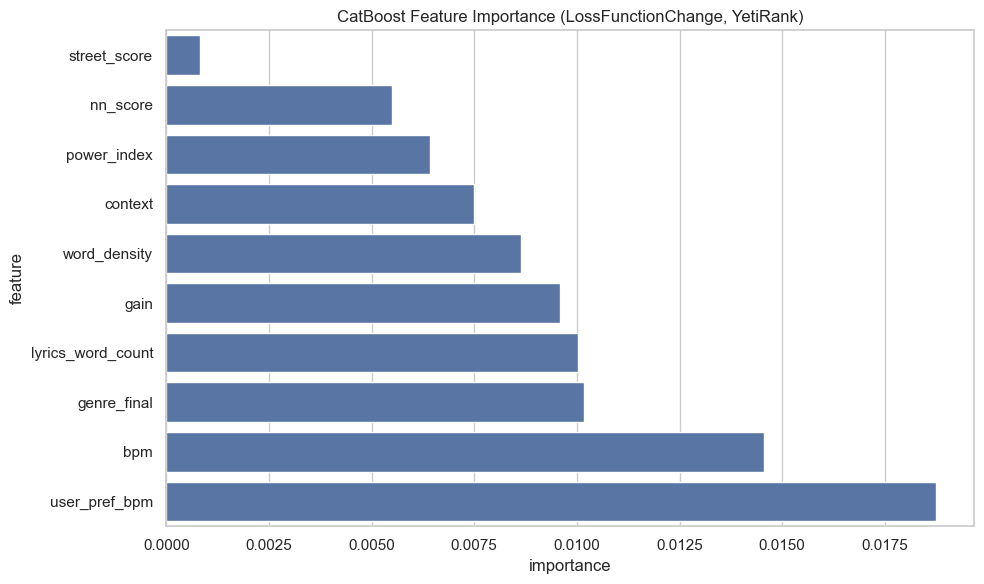

In [52]:
plt.figure(figsize=(10, 6))
importance = system.ranker.get_feature_importance(data=system.train_pool, type='LossFunctionChange')
importance_df = (
    pd.DataFrame({
        'feature': RANK_FEATURES,
        'importance': importance
    })
    .sort_values('importance', ascending=True)
)

sns.barplot(data=importance_df, x='importance', y='feature')
plt.title(
    'CatBoost Feature Importance '
    '(LossFunctionChange, YetiRank)'
)
plt.tight_layout()
plt.show()

#### t-SNE Визуализация

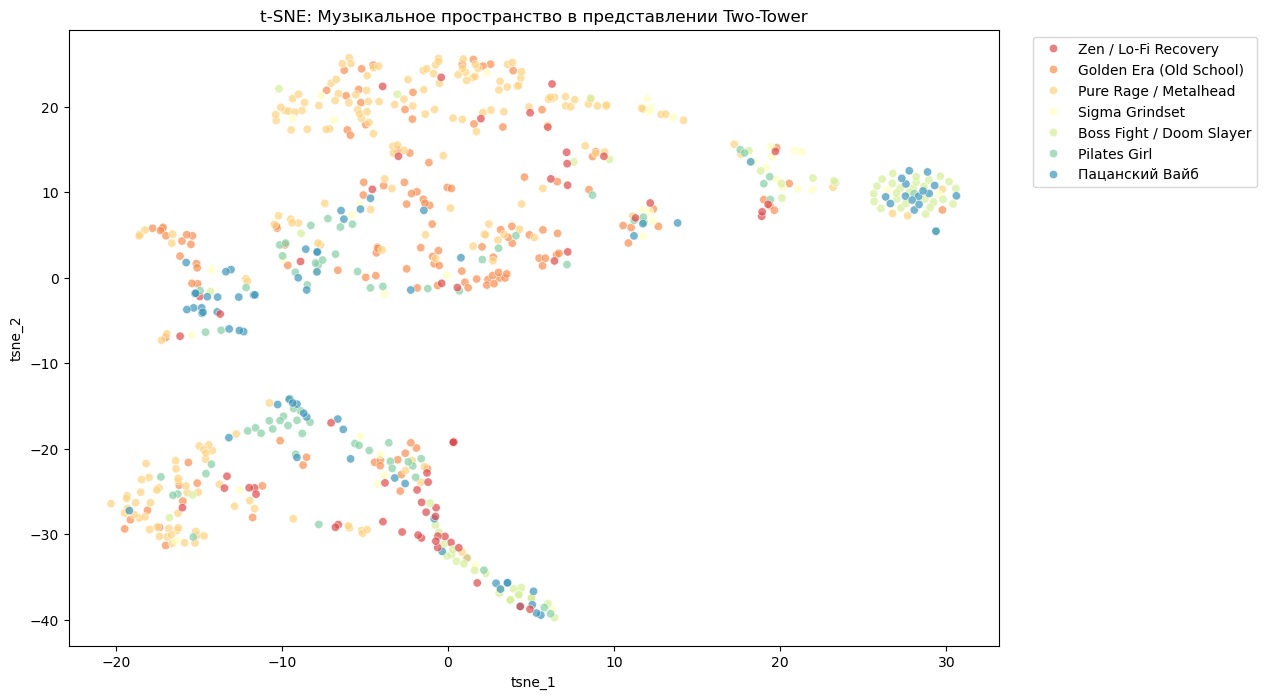

In [43]:
from sklearn.manifold import TSNE

system.model.eval()
with torch.no_grad():
    item_tensor = torch.tensor(system.catalogue[ITEM_FEATURES].to_numpy(dtype='float32'))
    embeddings = system.model.item_tower(item_tensor).numpy()

reduced = TSNE(n_components=2, perplexity=30, random_state=SEED).fit_transform(embeddings)
plot_df = system.catalogue.assign(tsne_1=reduced[:, 0], tsne_2=reduced[:, 1])
plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='tsne_1', y='tsne_2', hue='target', palette='Spectral', alpha=.7)
plt.title('t-SNE: Музыкальное пространство в представлении Two-Tower')
plt.legend(bbox_to_anchor=(1.03, 1), loc='upper left')
plt.show()